# Project 4: Unsupervised Image Clustering and Visualization

**Name:** OBAJE PAUL  
**Course:** MACHINE LEARNING

## Project Overview
In this project, I apply unsupervised learning to the MNIST handwritten-digit dataset. I preprocess the images, explore the data, use K-Means clustering to discover groups without using the digit labels during training, determine a suitable number of clusters with the elbow method, inspect cluster centroids, predict clusters for unseen images, and use PCA and t-SNE to visualize the cluster structure.

The true MNIST digit labels are retained only for interpretation and validation after clustering. They are not supplied to K-Means during training.


In [1]:
# Import the libraries used in the project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Preparation and Exploration

I loaded MNIST through Scikit-learn as required. MNIST contains grayscale handwritten digit images. Each 28 × 28 image is represented by 784 pixel values. I normalize the pixel values from 0–255 to 0–1 so that the features are on a consistent scale.


In [2]:
# Load MNIST through Scikit-learn
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

X = mnist.data.astype("float32")
y = mnist.target.astype("int64")

print("Original image matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Pixel range before normalization:", X.min(), "to", X.max())


Original image matrix shape: (70000, 784)
Label vector shape: (70000,)
Pixel range before normalization: 0.0 to 255.0


In [3]:
# Normalize pixel values to the range 0 to 1
X = X / 255.0

print("Pixel range after normalization:", X.min(), "to", X.max())
print("Number of features per image:", X.shape[1])


Pixel range after normalization: 0.0 to 1.0
Number of features per image: 784


### Working sample
The complete MNIST dataset is large, and K-Means and especially t-SNE can be computationally expensive. I therefore use a reproducible stratified sample of 12,000 images for the clustering analysis. This preserves representation from all ten digits while making the notebook practical to run in Google Colab.


In [4]:
# Create a stratified working sample
X_work, _, y_work, _ = train_test_split(
    X, y,
    train_size=12000,
    stratify=y,
    random_state=42
)

print("Working sample shape:", X_work.shape)
print("Digits represented:", np.unique(y_work))


Working sample shape: (12000, 784)
Digits represented: [0 1 2 3 4 5 6 7 8 9]


,count
0,1184
1,1350
2,1198
3,1224
4,1170
5,1082
6,1179
7,1250
8,1170
9,1193


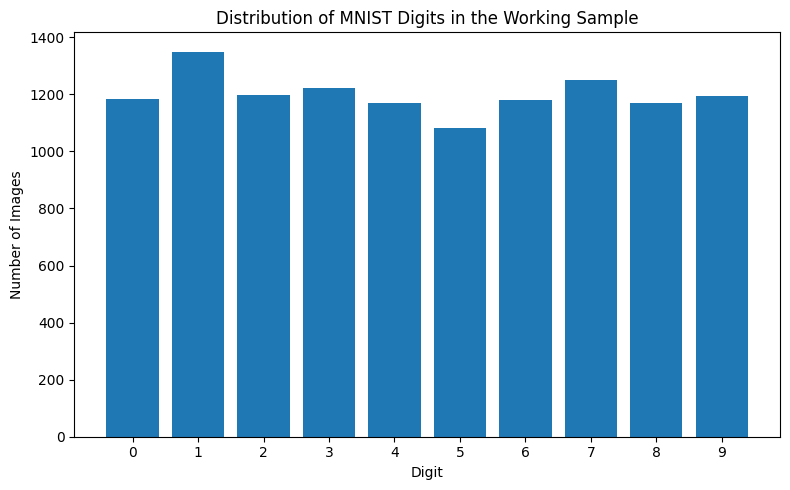

In [5]:
# Check the distribution of the true digit labels for exploration only
digit_counts = pd.Series(y_work).value_counts().sort_index()
display(digit_counts.to_frame("count"))

plt.figure(figsize=(8, 5))
plt.bar(digit_counts.index, digit_counts.values)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Distribution of MNIST Digits in the Working Sample")
plt.tight_layout()
plt.show()


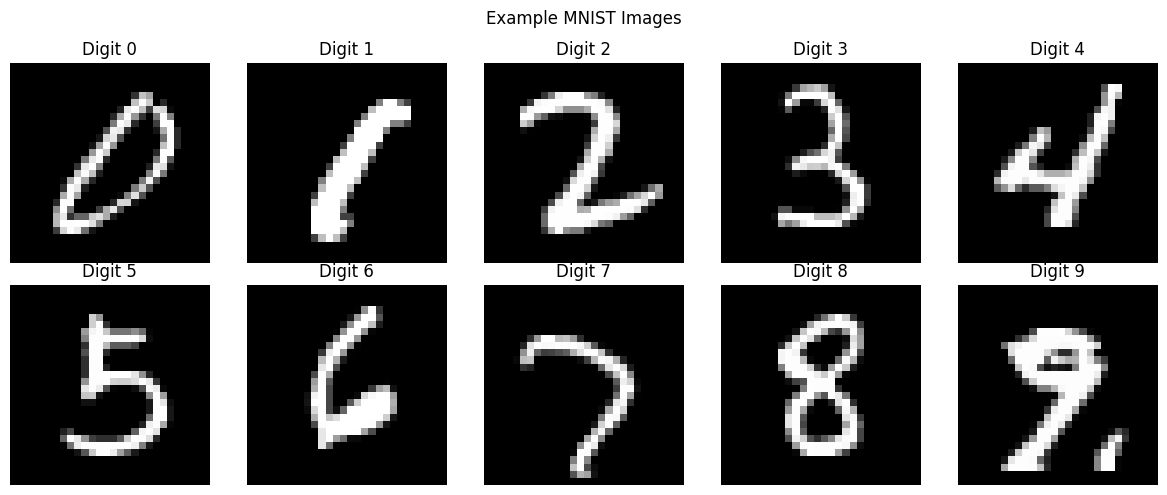

In [6]:
# Display one example of each digit
plt.figure(figsize=(12, 5))

for digit in range(10):
    index = np.where(y_work == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(X_work[index].reshape(28, 28), cmap="gray")
    plt.title(f"Digit {digit}")
    plt.axis("off")

plt.suptitle("Example MNIST Images")
plt.tight_layout()
plt.show()


### Exploration findings
The images have 784 numerical pixel features after flattening. Normalization changes only the scale of the pixels, not the image content. The digit distribution is reasonably balanced because I used stratified sampling. Visual inspection also shows substantial handwriting variation within the same digit, which means perfect separation should not be expected from a simple distance-based clustering algorithm.


In [7]:
# Split the working data into a clustering training set and a separate test set
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work,
    test_size=0.20,
    stratify=y_work,
    random_state=42
)

print("Training images:", X_train.shape)
print("Test images:", X_test.shape)


Training images: (9600, 784)
Test images: (2400, 784)


## 2. K-Means Clustering

K-Means groups observations by minimizing the distance between each image and the centroid of its assigned cluster. Because the algorithm is unsupervised, I do not pass the digit labels to the model.


In [8]:
# Use a smaller representative sample for the elbow calculation
X_elbow, _, _, _ = train_test_split(
    X_train, y_train,
    train_size=4000,
    stratify=y_train,
    random_state=42
)

k_values = range(2, 16)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_elbow)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias
})

display(elbow_results)


,k,inertia
0,2,197602.812500
1,3,188004.015625
2,4,180801.703125
3,5,173804.593750
4,6,168759.078125
5,7,165119.765625
6,8,161723.078125
7,9,158945.328125
8,10,156525.812500
9,11,154051.875000


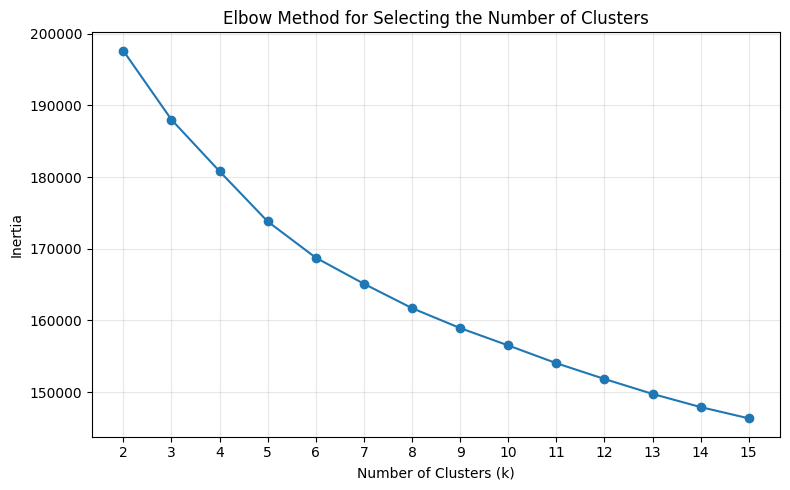

In [9]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting the Number of Clusters")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Elbow-method decision
I inspect the elbow plot rather than selecting a value only because MNIST contains ten known digit categories. If the bend is gradual, I use **k = 10** as a practical and interpretable choice because the objective is to investigate whether unsupervised groups recover structures related to the ten handwritten digits. This does not give K-Means access to the labels; the labels remain excluded from model fitting.


In [10]:
# Fit the final K-Means model
optimal_k = 10

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train)

print("K-Means training completed.")
print("Number of clusters:", optimal_k)
print("Training inertia:", kmeans.inertia_)


K-Means training completed.
Number of clusters: 10
Training inertia: 377795.0625


,images
0,1469
1,863
2,487
3,736
4,1161
5,1091
6,1399
7,533
8,931
9,930


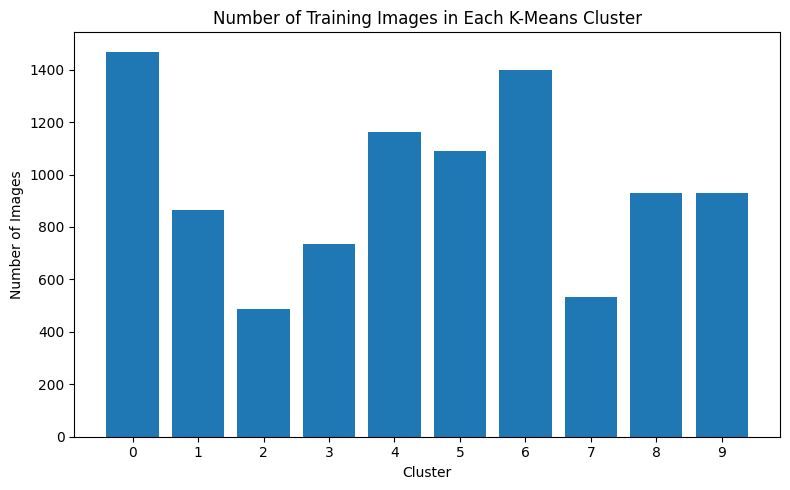

In [11]:
# Display the number of images assigned to each cluster
cluster_counts = pd.Series(train_clusters).value_counts().sort_index()
display(cluster_counts.to_frame("images"))

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Images")
plt.title("Number of Training Images in Each K-Means Cluster")
plt.xticks(range(optimal_k))
plt.tight_layout()
plt.show()


## 3. Cluster Centroid Analysis

Each K-Means centroid contains 784 average pixel values. I reshape each centroid back to 28 × 28 pixels so that I can visually interpret the typical image represented by each cluster.


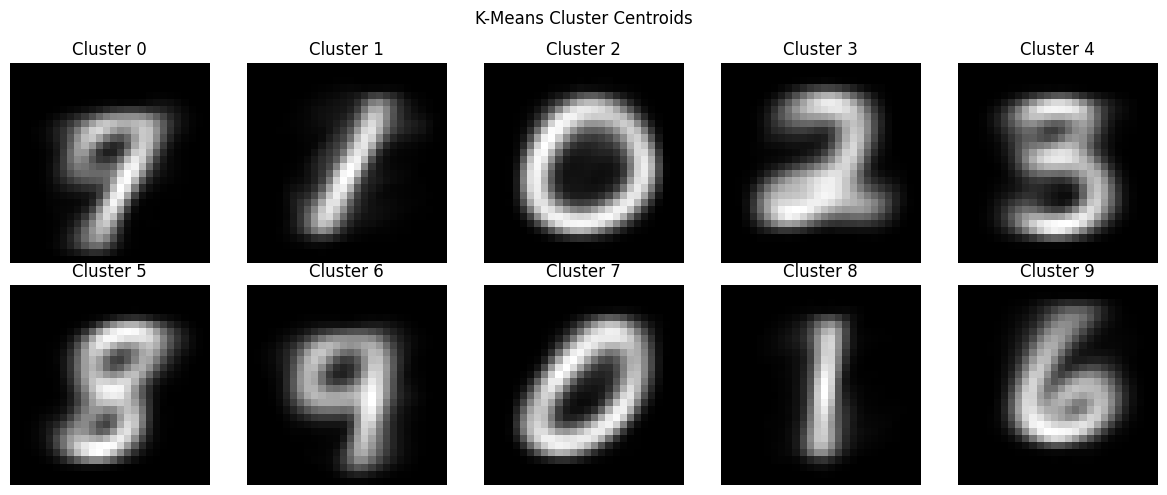

In [12]:
# Visualize cluster centroids as images
centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 5))

for cluster in range(optimal_k):
    plt.subplot(2, 5, cluster + 1)
    plt.imshow(centroids[cluster].reshape(28, 28), cmap="gray")
    plt.title(f"Cluster {cluster}")
    plt.axis("off")

plt.suptitle("K-Means Cluster Centroids")
plt.tight_layout()
plt.show()


In [13]:
# Compare clusters with true labels only AFTER clustering for interpretation
table = pd.crosstab(
    pd.Series(y_train, name="True Digit"),
    pd.Series(train_clusters, name="Cluster")
)

display(table)

dominant_digit = table.idxmax(axis=0)
print("\nDominant true digit in each cluster:")
print(dominant_digit)


Cluster,0,1,2,3,4,5,6,7,8,9
True Digit,,,,,,,,,,
0,2,2,420,2,20,35,5,436,0,25
1,1,437,0,2,1,3,2,0,634,0
2,11,84,1,662,44,32,26,17,47,34
3,8,12,1,41,607,195,34,15,59,7
4,317,41,0,7,0,6,501,1,18,45
5,67,107,12,3,303,233,52,49,19,21
6,0,27,38,5,3,14,16,7,46,787
7,645,52,4,4,0,2,254,1,38,0
8,22,84,4,9,172,559,32,4,40,10



Dominant true digit in each cluster:
Cluster
0    7
1    1
2    0
3    2
4    3
5    8
6    4
7    0
8    1
9    6
dtype: int64


### Interpretation
The centroid images show which handwriting patterns each cluster has learned. A clear digit-like centroid indicates that many visually similar images were grouped together. Some centroids may look less distinct because digits such as 3, 5, 8 or 9 can share strokes and shapes. The cross-tabulation is used only after training to interpret the clusters; it does not turn the analysis into supervised learning.


In [14]:
# Calculate unsupervised validation measures
sample_size = min(3000, len(X_train))
sample_ids = np.random.RandomState(42).choice(
    len(X_train), sample_size, replace=False
)

silhouette = silhouette_score(
    X_train[sample_ids],
    train_clusters[sample_ids]
)

ari_train = adjusted_rand_score(y_train, train_clusters)

# Cluster purity
cont = contingency_matrix(y_train, train_clusters)
purity = np.sum(np.max(cont, axis=0)) / np.sum(cont)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index: {ari_train:.4f}")
print(f"Cluster Purity: {purity:.4f}")


Silhouette Score: 0.0583
Adjusted Rand Index: 0.3647
Cluster Purity: 0.5925


### What do the evaluation measures mean?
- **Silhouette score** measures how compact and separated the clusters are. Values closer to 1 indicate stronger separation, while values near 0 indicate overlap.
- **Adjusted Rand Index (ARI)** compares the discovered clusters with the known digit labels for validation. K-Means never sees these labels during training.
- **Cluster purity** shows the proportion of observations that agree with the dominant true digit within each cluster.

I do not expect these measures to be perfect because K-Means assumes roughly compact distance-based groups, while handwritten digits contain different writing styles and some visually overlapping shapes.


## 4. Prediction on Separate Images

I use the fitted K-Means model to assign cluster labels to the held-out test images. This demonstrates how new images can be associated with the nearest learned centroid.


In [15]:
# Predict cluster assignments for unseen test images
test_clusters = kmeans.predict(X_test)

print("Predicted cluster labels for the first 20 test images:")
print(test_clusters[:20])


Predicted cluster labels for the first 20 test images:
[4 4 1 4 7 6 5 5 0 2 6 6 0 1 4 1 0 1 0 6]


In [16]:
# Map each cluster to its dominant training digit for interpretation
cluster_to_digit = {
    cluster: int(dominant_digit.loc[cluster])
    for cluster in dominant_digit.index
}

mapped_test_digits = np.array([
    cluster_to_digit[cluster]
    for cluster in test_clusters
])

test_ari = adjusted_rand_score(y_test, test_clusters)
mapped_accuracy = np.mean(mapped_test_digits == y_test)

print(f"Test Adjusted Rand Index: {test_ari:.4f}")
print(f"Dominant-cluster mapping agreement: {mapped_accuracy:.4f}")


Test Adjusted Rand Index: 0.3579
Dominant-cluster mapping agreement: 0.5933


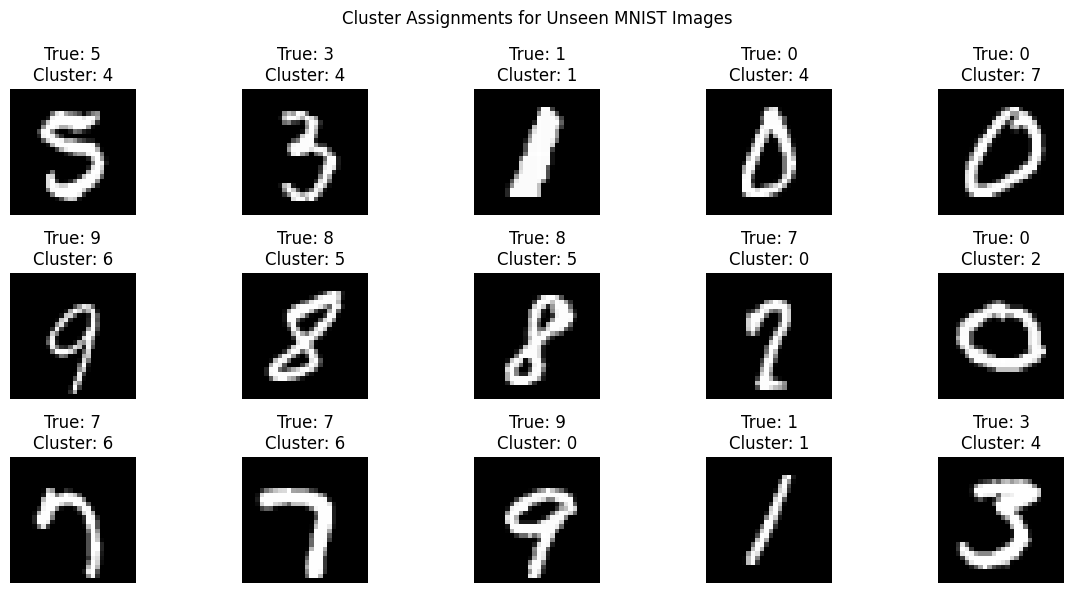

In [17]:
# Display new test images and their assigned clusters
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(
        f"True: {y_test[i]}\n"
        f"Cluster: {test_clusters[i]}"
    )
    plt.axis("off")

plt.suptitle("Cluster Assignments for Unseen MNIST Images")
plt.tight_layout()
plt.show()


### Prediction findings
The test predictions show that K-Means can assign previously unseen images to existing groups without retraining. I compare these assignments with the original labels only as a validation step. Misalignment is expected when several handwriting styles for one digit form separate visual patterns or when different digits have similar pixel structures.


## 5. PCA Dimensionality Reduction and Visualization

PCA creates linear combinations of the original pixel features that preserve as much variance as possible. I reduce the 784-dimensional images to two principal components for visualization.


In [18]:
# Reduce the training data to two dimensions with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

print("PCA output shape:", X_pca.shape)
print("Variance explained by PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Variance explained by PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total variance explained:", round(pca.explained_variance_ratio_.sum(), 4))


PCA output shape: (9600, 2)
Variance explained by PC1: 0.0975
Variance explained by PC2: 0.072
Total variance explained: 0.1695


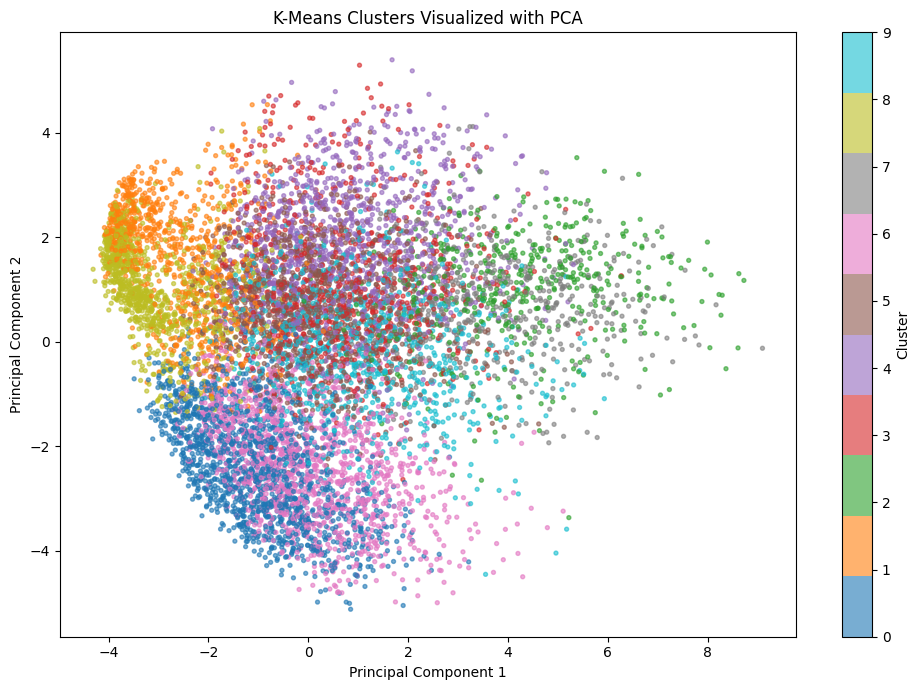

In [19]:
# Visualize K-Means clusters in PCA space
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=train_clusters,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


### PCA interpretation
The PCA plot provides a global two-dimensional view of the data. Some overlap is expected because two components cannot preserve all information contained in 784 pixel features. Therefore, overlap in the PCA plot does not automatically mean that the original high-dimensional clusters are identical.


## 6. t-SNE Dimensionality Reduction and Visualization

t-SNE is a nonlinear dimensionality-reduction technique that is especially useful for visualizing local neighborhood structure. Because t-SNE is computationally expensive, I use a reproducible sample of 2,500 training images.


In [20]:
# Select a reproducible subset for t-SNE
rng = np.random.RandomState(42)
tsne_size = min(2500, len(X_train))
tsne_ids = rng.choice(len(X_train), tsne_size, replace=False)

X_tsne_input = X_train[tsne_ids]
tsne_clusters = train_clusters[tsne_ids]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto",
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_tsne_input)

print("t-SNE output shape:", X_tsne.shape)


t-SNE output shape: (2500, 2)


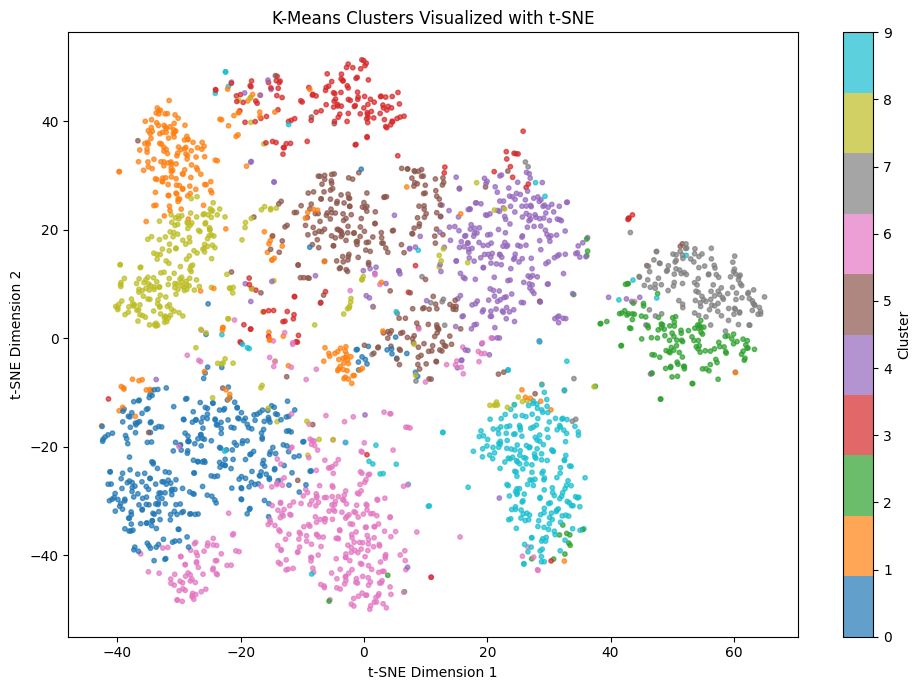

In [21]:
# Visualize K-Means clusters in t-SNE space
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=tsne_clusters,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("K-Means Clusters Visualized with t-SNE")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


### PCA versus t-SNE
PCA is a linear method and is useful for showing broad variance patterns. t-SNE is nonlinear and tends to reveal local groups more clearly, although the distances between separate t-SNE groups should not be interpreted as exact global distances. I therefore use both methods because they provide complementary views of the clustering structure.


## 7. Final Summary and Answers

### What preprocessing was performed?
I loaded MNIST through Scikit-learn, converted the labels to integers for later interpretation, normalized all pixel values from 0–255 to 0–1, and kept the images flattened as 784-element vectors for clustering. I used a stratified working sample to make K-Means and t-SNE computationally practical.

### How was the number of clusters selected?
I calculated K-Means inertia for several values of k and plotted the elbow curve. I used k = 10 as an interpretable final choice after examining the curve and considering that the data contain ten types of handwritten digits. The true labels were not used to fit K-Means.

### What do the centroids represent?
Each centroid is the average 784-dimensional image for a cluster. After reshaping a centroid to 28 × 28 pixels, it shows the typical stroke pattern learned for that cluster.

### Can K-Means predict a cluster for a new image?
Yes. After training, `kmeans.predict()` assigns a new normalized 784-pixel image to the nearest learned centroid. I demonstrated this using a held-out test set.

### How was the clustering validated?
I used a silhouette score to examine internal cluster separation. I also used the known MNIST labels only after clustering to calculate the Adjusted Rand Index, cluster purity, and to interpret the dominant digit associated with each cluster.

### What did PCA contribute?
PCA compressed the 784 pixel features into two linear components. It provided a broad view of the cluster structure, although some information was necessarily lost.

### What did t-SNE contribute?
t-SNE provided a nonlinear two-dimensional visualization that emphasizes local neighborhoods. It is useful for seeing groups that may overlap in a simple PCA projection.

### Overall conclusion
This project showed me that unsupervised learning can identify meaningful visual structure without being given predefined class labels. K-Means can discover groups that often correspond to digit-like patterns, but the relationship is not perfect because handwriting styles overlap and K-Means relies on Euclidean distance. PCA and t-SNE helped me inspect the learned structure from different perspectives. The project also demonstrated how a fitted clustering model can assign unseen images to previously learned groups.
